# Example Firefly usage

This builds off of the [minimal example](https://firefly.rcs.northwestern.edu/docs/data_reader/minimal_example.html) from our docs and the new [data selection example](https://github.com/ageller/Firefly/blob/main/src/firefly/ntbks/selecting_data.ipynb) from our GitHub repo.


As an example, we will generate two random particle sets (a sphere and a cube) both with a randomized attribute field.  We will load these data into Firefly.

This notebook also demonstrates how to retrieve data that you selected by hand in the Firefly app and then use those data with your notebook. 

In [1]:
import numpy as np
from astropy.table import Table
from astropy import units as u
from astropy.coordinates import SkyCoord

In [2]:
# Load your data. Here we're creating random data.

orb_hf = Table.read('~/Downloads/cra2_model_orbit_gui.csv')

# Create a coordinate object with RA, Dec, and a distance (e.g., in parsecs)
coord = SkyCoord(ra=orb_hf['ra'] * u.deg, dec=orb_hf['dec'] * u.deg, distance=orb_hf['dist'] * u.kpc)

# Extract Cartesian X, Y, Z values
orb_hf['x'] = coord.cartesian.x.value
orb_hf['y'] = coord.cartesian.y.value
orb_hf['z'] = coord.cartesian.z.value

coords = np.array([orb_hf['x'],orb_hf['y'],orb_hf['z']]).T

In [3]:
orb_hf

ra,dec,dist,pmra,pmdec,rv,x,y,z
float64,float64,float64,float64,float64,float64,float64,float64,float64
166.29021463659265,-24.228998702997323,161.47216816876815,-0.028910125776788143,-0.055328300821161094,163.94145363756783,-143.05318574477053,34.89849221512827,-66.26569536725437
-151.10167926381445,1.6760918619446377,53.38802270481304,-0.03740954094647559,-0.2285270749986072,-111.99043129252519,-46.720078588969464,-25.789082443536763,1.561554254777559
177.08151005481824,-18.334519570473883,117.81669080188408,-0.0573111812481545,-0.09829489839282927,88.97586912941424,-111.69080622191484,5.694149034221387,-37.06093770780094
-176.86845822720056,-14.683821051478017,93.65135090016362,-0.0723993494894091,-0.1349841953431708,41.342382500568434,-90.45736109837706,-4.948940596127822,-23.739194078978247
165.1552240781287,-25.262791758730387,167.91739898278414,-0.026644260172565336,-0.0497319120707702,172.52107148796154,-146.78927439450092,38.90614644932674,-71.66221858373467
177.3882922257959,-18.161939462925826,115.68091643175977,-0.06398570478219627,-0.10439750320932394,88.08232998939633,-109.8034408645977,5.00862869631754,-36.058181309780544
177.07239963666035,-18.47636617076365,115.74341174770085,-0.06596634770344573,-0.09154644644368197,87.35290949280014,-109.634081224763,5.606772414242889,-36.68064476116485
177.06748927411763,-18.619235882883846,115.89136832960052,-0.06549159286055636,-0.10285465288106921,88.88546691603575,-109.68194354648017,5.618644717746274,-37.00150462764471
174.96870354342448,-19.698717989286088,129.02879464191173,-0.05495222042341062,-0.08616231044526178,109.71214289712618,-121.00972191729787,10.653586652768235,-43.49227678191644


## Format Data for Firefly

Here are the docs for [Reader](https://firefly.rcs.northwestern.edu/docs/reference/api/classes/firefly.data_reader.Reader.html#firefly.data_reader.Reader) and [ParticleGroup](https://firefly.rcs.northwestern.edu/docs/reference/api/classes/firefly.data_reader.ParticleGroup.html#firefly.data_reader.ParticleGroup) and also [a tutorial for using these](https://firefly.rcs.northwestern.edu/docs/data_reader/reader_tutorial.html).  Also note that for simple data (e.g., one particle group), you can use the [ArrayReader](https://firefly.rcs.northwestern.edu/docs/reference/api/readers/firefly.data_reader.ArrayReader.html) class.

In [4]:
from firefly.data_reader import ParticleGroup, Reader

In [5]:
# create two Firefly particle groups
cra2_sim = ParticleGroup(
    'Cra2 Nbody',
    coords,
    field_arrays=[np.array(orb_hf['pmra']),np.array(orb_hf['pmdec']),np.array(orb_hf['rv'])], 
    field_names=['pmra','pmdec','rv']
) 

# create the Reader
my_reader = Reader()

# add the particle groups to the reader
my_reader.addParticleGroup(cra2_sim)

Make sure each field_array (3) has a field_filter_flag (0), assuming True.
Make sure each field_array (3) has a field_colormap_flag (0), assuming True.
Make sure each field_array (3) has a field_radius_flag (0), assuming False.
datadir is None, defaulting to /opt/anaconda3/envs/firefly/lib/python3.14/site-packages/firefly/static/data/Data


## Display Inline

In [6]:
# Firefly was built using the `eventlet` library, which is now deprecated.  (We still need to migrate to a newer library.)
# Let's silence the deprecation warnings
import warnings
warnings.filterwarnings('ignore')

In [7]:
from firefly.server import spawnFireflyServer,quitAllFireflyServers

In [25]:
# define the local port (typically anything in 5000 - 8000 range)
port = 5500

In [26]:
# Note: you should only run this cell once.  You only want one single Firefly server running at time on your machine.
# If you've already run this cell and need to restart the server for some reason, the best thing to do is to restart your notebook kernel.
# (You can continue to send new data to the existing server, within needing to re-run this cell.)
process = spawnFireflyServer(port, method = 'flask')

Waiting up to 10 seconds for background Firefly server to start...done! Your server is available at - http://localhost:5500


In [27]:
from IPython.display import IFrame
url = f'http://localhost:{port:d}/combined'
IFrame(url, width=1000, height=500)

In [28]:
# Send data to the server.
# Wait until it loads to run this command
my_reader.sendDataViaFlask()

Cra2 Nbody - 40000/40000 particles - 3 tracked fields
Posting data on port 5500...data posted!


## Get the selected data in Python

(after using the selection tool)

In [23]:
import requests

import matplotlib.pyplot as plt
%matplotlib inline

In [24]:
# send a get request to receive the current settings from Firefly
# for larger amounts of data, you will need to increase the waitTime (in seconds) via params (see below; the default is 10s)
r = requests.get(url = f'http://localhost:{port:d}/get_selected_data', params = {'waitTime':60})
if r.status_code == 200:
    # success
    selection = r.json()
    # as a check
    partsKeys = list(selection.keys())
    print(partsKeys)
    print(selection[partsKeys[0]]['Coordinates_flat'][:100]) 
else:
    print('Error: {}'.format(r.status_code), r.content)


['sphere', 'cube']
[-1.8435493039, -0.0601345628, 0.0901424813, -0.529503139, -0.4431704685, -0.2508552812, -0.4168067683, 0.2540403718, -0.3761472847, -1.0392055654, 0.0110528935, -0.0457405486, -0.6282851255, -0.5594334644, 0.2145068715, -0.2725105194, -0.4795322945, 0.3784405112, -0.2396836743, -0.2653008402, 0.1532975381, -0.8320095475, -0.3316109162, -0.1807695645, -1.0256776493, 0.7278644112, 0.4473065495, -0.6586731701, 0.3109402612, -0.3888966908, -0.5114055359, -0.1392024243, -0.0358098176, -0.6007733737, 0.0797609185, -0.6760515646, -0.7546065352, 0.9915149195, 0.1805499415, -0.6720021833, -0.1928587514, 0.6141624805, -0.1574585093, -0.3197701436, -0.3840111896, -1.4873222495, -0.1569638938, 0.2981598155, -0.7146971908, 0.3984280074, 0.4592128839, -1.4477661728, -0.1430743155, -0.3731687183, -0.8358486036, 0.4815852272, -0.5491774514, -1.0719819591, -0.0305524443, 0.7150511638, -1.2655531773, 0.4787194987, -0.1031008317, -1.6029992122, 0.2109744012, -0.2730918971, -0.64692251

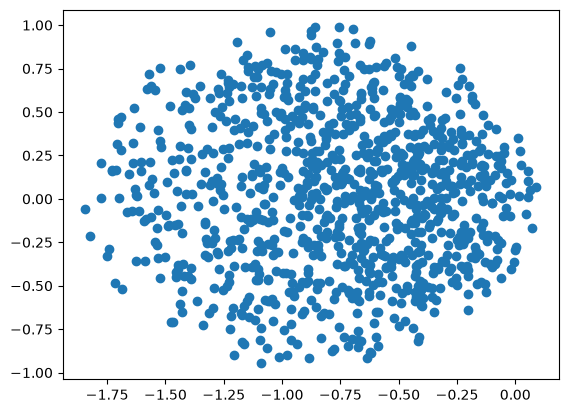

In [25]:
# plot x, y for the selected points
partsKeys = list(selection.keys())
part0 = selection[partsKeys[0]]

# UPDATE THIS
x = part0['Coordinates_flat'][0::3]
y = part0['Coordinates_flat'][1::3]

f, ax = plt.subplots()
ax.scatter(x[:1000],y[:1000])

### Quit the Firefly server

... this doesn't always work in a notebook ... you can also quit the server by resetting the kernel.

In [29]:
return_code = quitAllFireflyServers()

Server output:
--------------
Launching Firefly at: http://localhost:6500
from directory /opt/anaconda3/envs/firefly/lib/python3.14/site-packages/firefly
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= sid yImz1PYurVe1J6wdAAAB disconnected from room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= sid nkYkPcH7B6EMGYuRAAAD disconnected from room default_Firefly_AMG_ABG
Launching Firefly at: http://localhost:5500
from directory /opt/anaconda3/envs/firefly/lib/python3.14/site-packages/firefly
======= socket connected
======= connected {'data': 'GUI connected!'}
======= socket connected
======= connected {'data': 'Viewer connected!'}
======= in room default